# 01 — Data Preparation

Convert raw `.mat` files for one dataset into:

- grayscale **256×256 PNG** images at `data/<dataset>/processed/images/<image_id>.png`
- binary **256×256 PNG** masks at `data/<dataset>/processed/masks/<image_id>.png`
- `data/<dataset>/processed/metadata.csv`
- `data/<dataset>/processed/metadata_summary.csv`
- `data/<dataset>/processed/preprocessing_config.json`
- a QA grid at `outputs/figures/data_preparation/<dataset>/class_examples_grid.png`

NB01 writes **directly to Drive** (per dev/run doc § 7) — it's a one-time write per dataset, not in the heavy-write training hot path, so the Drive-FUSE freeze risk doesn't apply here.

**To switch datasets:** change `DATASET` in cell 3. No source-code edits needed once a converter for that dataset exists in `src/preprocess_utils.py`.

## Cell 1 — Install dependencies

In [1]:
%pip install -q kagglehub h5py opencv-python-headless pillow numpy pandas matplotlib tqdm

## Cell 2 — Bootstrap: mount Drive + clone/pull repo

In [2]:
import os, sys

# Bootstrap shim: clone the repo if missing, then add to sys.path.
# After this, src.* imports work and notebook_setup takes over.
if not os.path.exists("/content/senior_project"):
    from google.colab import userdata
    try:
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = None
    url = "https://github.com/salemaker47/senior_project.git"
    if token:
        url = url.replace("https://", f"https://{token}@", 1)
    os.system(f"git clone {url} /content/senior_project")
if "/content/senior_project" not in sys.path:
    sys.path.insert(0, "/content/senior_project")

from src.notebook_setup import setup_environment

DRIVE_ROOT, REPO_ROOT = setup_environment(
    repo_url="https://github.com/salemaker47/senior_project.git",
)

# NB01 exception: write directly to Drive (one-time, not in training hot path).
PROJECT_ROOT = DRIVE_ROOT

print(f"DRIVE_ROOT:   {DRIVE_ROOT}")
print(f"REPO_ROOT:    {REPO_ROOT}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

Mounted at /content/drive
DRIVE_ROOT:   /content/drive/MyDrive/Senior_Project
REPO_ROOT:    /content/senior_project
PROJECT_ROOT: /content/drive/MyDrive/Senior_Project


## Cell 3 — Knobs

The single source of configuration for this notebook. Change `DATASET` to switch datasets.

In [3]:
DATASET              = "figshare"
KAGGLEHUB_DATASET_ID = "ashkhagan/figshare-brain-tumor-dataset"
TARGET_SIZE          = (256, 256)
NORMALIZATION        = "percentile"   # or "minmax"
RANDOM_SEED          = 42

assert DATASET in ("figshare", "brats2024"), f"unsupported DATASET: {DATASET}"
print(f"DATASET = {DATASET}")

DATASET = figshare


## Cell 4 — Resolve dataset paths

In [4]:
from src.file_utils import dataset_paths

paths = dataset_paths(PROJECT_ROOT, DATASET)
for k, v in paths.items():
    print(f"  {k}: {v}")

  dataset_root: /content/drive/MyDrive/Senior_Project/data/figshare
  raw: /content/drive/MyDrive/Senior_Project/data/figshare/raw
  processed: /content/drive/MyDrive/Senior_Project/data/figshare/processed
  images: /content/drive/MyDrive/Senior_Project/data/figshare/processed/images
  masks: /content/drive/MyDrive/Senior_Project/data/figshare/processed/masks
  metadata_csv: /content/drive/MyDrive/Senior_Project/data/figshare/processed/metadata.csv
  metadata_summary_csv: /content/drive/MyDrive/Senior_Project/data/figshare/processed/metadata_summary.csv
  preprocessing_config_json: /content/drive/MyDrive/Senior_Project/data/figshare/processed/preprocessing_config.json
  splits: /content/drive/MyDrive/Senior_Project/data/figshare/splits
  figures_dataprep: /content/drive/MyDrive/Senior_Project/outputs/figures/data_preparation/figshare


## Cell 5 — Download raw `.mat` files via KaggleHub

KaggleHub caches in `/root/.cache/kagglehub/` (Colab local SSD). The download is fast on local SSD; we then process from there directly without copying to Drive's `raw/` (it would be a slow Drive write of ~870 MB and the kagglehub cache is reproducible from the dataset id alone).

In [5]:
import kagglehub

download_path = kagglehub.dataset_download(KAGGLEHUB_DATASET_ID)
print(f"Downloaded to: {download_path}")

100%|██████████| 839M/839M [00:11<00:00, 78.7MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/ashkhagan/figshare-brain-tumor-dataset/versions/1


## Cell 6 — Discover `.mat` samples

In [6]:
from src.preprocess_utils import discover_mat_files, DATASET_NAME

# Sanity: the converter is figshare-specific; new datasets need new branches in
# preprocess_utils per the registry pattern (project instruction §5).
assert DATASET == DATASET_NAME, (
    f"DATASET ({DATASET}) must match preprocess_utils.DATASET_NAME ({DATASET_NAME}). "
    f"To process a different dataset, add a converter and update this assert."
)

mat_files = discover_mat_files(download_path)
print(f"Found {len(mat_files)} .mat samples")
print(f"First 3: {[p.name for p in mat_files[:3]]}")
print(f"Last 3:  {[p.name for p in mat_files[-3:]]}")

Found 3064 .mat samples
First 3: ['1.mat', '2.mat', '3.mat']
Last 3:  ['3062.mat', '3063.mat', '3064.mat']


## Cell 7 — Convert each `.mat` to PNG + collect metadata records

This is the slow cell — ~3,000 conversions, each writes 2 PNGs to Drive. Expect a few minutes.

In [7]:
from tqdm.auto import tqdm
from src.preprocess_utils import convert_figshare_mat_to_png_record

records = []
for mat_path in tqdm(mat_files, desc="Converting"):
    rec = convert_figshare_mat_to_png_record(
        mat_path=mat_path,
        image_out_dir=paths["images"],
        mask_out_dir=paths["masks"],
        target_size=TARGET_SIZE,
        normalization=NORMALIZATION,
        path_style="relative",
        project_root=PROJECT_ROOT,
    )
    records.append(rec)

print(f"Converted {len(records)} samples")

Converting:   0%|          | 0/3064 [00:00<?, ?it/s]

Converted 3064 samples


## Cell 8 — Build and save `metadata.csv`

In [8]:
import pandas as pd

metadata_df = pd.DataFrame(records)
print(f"metadata_df shape: {metadata_df.shape}")
print()
print(metadata_df.head())

metadata_df.to_csv(paths["metadata_csv"], index=False)
print(f"\nSaved {paths['metadata_csv']}")

metadata_df shape: (3064, 12)

  image_id patient_id                            image_path  \
0        1     100360  data/figshare/processed/images/1.png   
1        2     100360  data/figshare/processed/images/2.png   
2        3     100360  data/figshare/processed/images/3.png   
3        4     100360  data/figshare/processed/images/4.png   
4        5     100360  data/figshare/processed/images/5.png   

                             mask_path tumor_class  tumor_class_id   dataset  \
0  data/figshare/processed/masks/1.png  meningioma               1  figshare   
1  data/figshare/processed/masks/2.png  meningioma               1  figshare   
2  data/figshare/processed/masks/3.png  meningioma               1  figshare   
3  data/figshare/processed/masks/4.png  meningioma               1  figshare   
4  data/figshare/processed/masks/5.png  meningioma               1  figshare   

                                     source_mat_path  height  width  \
0  /root/.cache/kagglehub/datasets/ash

## Cell 9 — Save `preprocessing_config.json`

In [9]:
from datetime import datetime, timezone
from src.file_utils import save_json

config = {
    "dataset":              DATASET,
    "kagglehub_dataset_id": KAGGLEHUB_DATASET_ID,
    "target_size":          list(TARGET_SIZE),
    "normalization":        NORMALIZATION,
    "mask_threshold":       127,
    "image_format":         "grayscale_uint8_png",
    "mask_format":          "binary_uint8_png_0_255",
    "n_samples":            int(len(metadata_df)),
    "random_seed":          RANDOM_SEED,
    "generated_at":         datetime.now(timezone.utc).isoformat(),
}
save_json(config, paths["preprocessing_config_json"])
print(f"Saved {paths['preprocessing_config_json']}")

Saved /content/drive/MyDrive/Senior_Project/data/figshare/processed/preprocessing_config.json


## Cell 10 — Per-class summary table

In [10]:
summary = (
    metadata_df.groupby("tumor_class")
    .agg(
        n_images=("image_id", "count"),
        n_patients=("patient_id", "nunique"),
        mean_mask_area_ratio=("mask_area_ratio", "mean"),
        median_mask_area_ratio=("mask_area_ratio", "median"),
    )
    .reset_index()
)
print(summary)

summary.to_csv(paths["metadata_summary_csv"], index=False)
print(f"\nSaved {paths['metadata_summary_csv']}")

  tumor_class  n_images  n_patients  mean_mask_area_ratio  \
0      glioma      1426          89              0.022043   
1  meningioma       708          82              0.017755   
2   pituitary       930          62              0.008359   

   median_mask_area_ratio  
0                0.018372  
1                0.015198  
2                0.006653  

Saved /content/drive/MyDrive/Senior_Project/data/figshare/processed/metadata_summary.csv


## Cell 11 — Visual QA: random examples per class

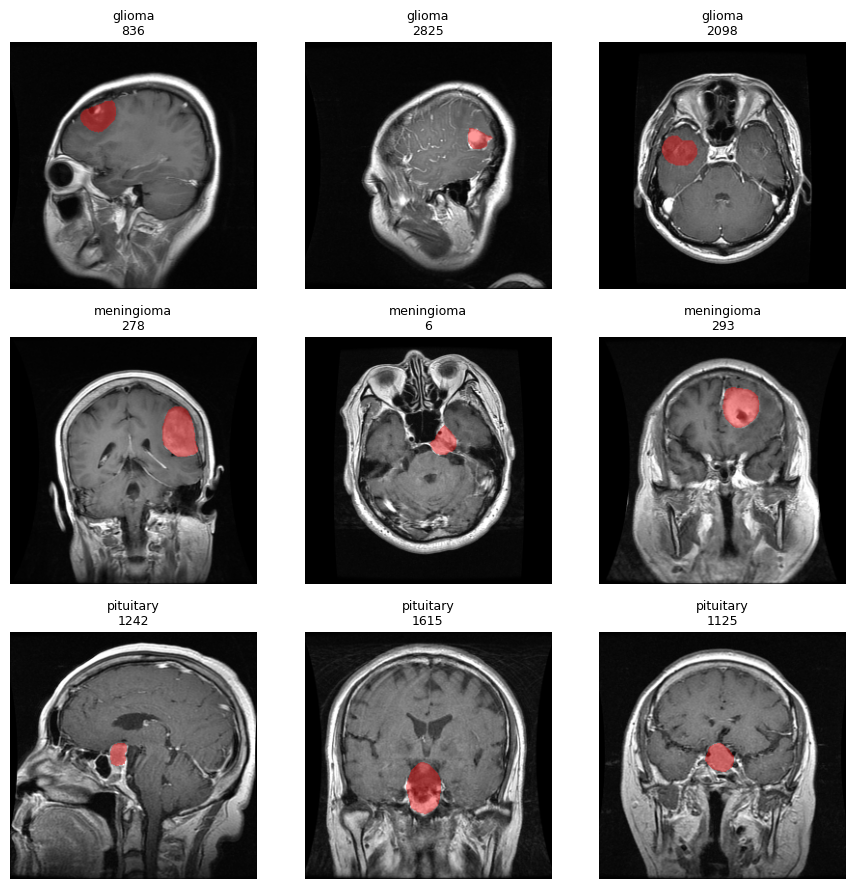


Saved QA figure: /content/drive/MyDrive/Senior_Project/outputs/figures/data_preparation/figshare/class_examples_grid.png


In [11]:
from src.vis_utils import show_class_examples

qa_save_path = paths["figures_dataprep"] / "class_examples_grid.png"
show_class_examples(
    metadata_df=metadata_df,
    project_root=PROJECT_ROOT,
    n_per_class=3,
    random_state=RANDOM_SEED,
    save_path=qa_save_path,
)
print(f"\nSaved QA figure: {qa_save_path}")

## Done.

You now have, on Drive:

- `data/<DATASET>/processed/images/<image_id>.png`
- `data/<DATASET>/processed/masks/<image_id>.png`
- `data/<DATASET>/processed/metadata.csv`
- `data/<DATASET>/processed/metadata_summary.csv`
- `data/<DATASET>/processed/preprocessing_config.json`
- `outputs/figures/data_preparation/<DATASET>/class_examples_grid.png`

Next: **NB02 (`02_split.ipynb`)** — generate 5-fold CSVs for both `patient_level` and `image_level` schemes.